In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "https://gregarious-kangaroo-062b33.netlify.app/"
res = requests.get(url)
soup = BeautifulSoup(res.text, "html.parser")
title = soup.title.text.strip()
tables = soup.find_all("table")
rows = soup.find_all("tr")
bodies = soup.find_all("tbody")
res.status_code, title, len(tables), len(rows), len(bodies)

(200, 'IT Salary Bands Europe 2026 — TalentUp', 1, 1, 1)

In [2]:
table = tables[0]
cells = table.find_all(["th", "td"])
texts = []
for cell in cells:
    texts.append(cell.get_text(" ", strip=True))
len(texts), texts

(6, ['Страна', 'Роль', 'Мин €', 'Макс €', 'Диапазон', 'Уровень'])

In [3]:
scripts = soup.find_all("script")
src_list = []
for s in scripts:
    src = s.get("src")
    if src:
        src_list.append(src)
src_list

[]

In [4]:
inline_scripts = []
for s in scripts:
    text = s.get_text(" ", strip=True)
    if text:
        inline_scripts.append(text)
len(inline_scripts), [x[:300] for x in inline_scripts[:5]]

(1,
 ['const DATA = {"Austria":{"Applications Developer":{"sme":[43,52],"st":[52,59],"co":[56,60]},"Automation Engineer":{"sme":[36,43],"st":[47,54],"co":[48,57]},"Backend Developer":{"sme":[42,52],"st":[53,71],"co":[62,86]},"BI Analyst":{"sme":[40,48],"st":[44,51],"co":[44,51]},"BI Developer":{"sme":[41,5'])

In [7]:
import json

script_text = inline_scripts[0]
data_text = script_text.split("const DATA = ", 1)[1]
data_text = data_text.split(";", 1)[0]
data = json.loads(data_text)
countries = list(data.keys())
first_country = countries[0]
roles = list(data[first_country].keys())
len(countries), first_country, len(roles), roles[:5]

(25,
 'Austria',
 27,
 ['Applications Developer',
  'Automation Engineer',
  'Backend Developer',
  'BI Analyst',
  'BI Developer'])

In [8]:
country = countries[0]
role = roles[0]
one_role = data[country][role]
country, role, one_role

('Austria',
 'Applications Developer',
 {'sme': [43, 52], 'st': [52, 59], 'co': [56, 60]})

In [10]:
levels = list(one_role.keys())
level = levels[0]
one_row = {
    "country": country,
    "role": role,
    "level": level,
    "min_eur": one_role[level][0],
    "max_eur": one_role[level][1],
}
one_row

{'country': 'Austria',
 'role': 'Applications Developer',
 'level': 'sme',
 'min_eur': 43,
 'max_eur': 52}

In [14]:
rows = []
for country in countries:
    roles_country = data[country]
    for role in roles_country:
        levels = roles_country[role]
        for level in levels:
            row = {
                "country": country,
                "role": role,
                "level": level,
                "min_eur": levels[level][0],
                "max_eur": levels[level][1],
            }
            rows.append(row)
table = pd.DataFrame(rows)
table.shape

(2025, 5)

In [16]:
head = table.head(10)
levels = table["level"].unique().tolist()
head, levels

(   country                    role level  min_eur  max_eur
 0  Austria  Applications Developer   sme       43       52
 1  Austria  Applications Developer    st       52       59
 2  Austria  Applications Developer    co       56       60
 3  Austria     Automation Engineer   sme       36       43
 4  Austria     Automation Engineer    st       47       54
 5  Austria     Automation Engineer    co       48       57
 6  Austria       Backend Developer   sme       42       52
 7  Austria       Backend Developer    st       53       71
 8  Austria       Backend Developer    co       62       86
 9  Austria              BI Analyst   sme       40       48,
 ['sme', 'st', 'co'])

In [17]:
table["range_eur"] = table["max_eur"] - table["min_eur"]
table = table[["country", "role", "level", "min_eur", "max_eur", "range_eur"]]
table.head(10)

,country,role,level,min_eur,max_eur,range_eur
0,Austria,Applications Developer,sme,43,52,9
1,Austria,Applications Developer,st,52,59,7
2,Austria,Applications Developer,co,56,60,4
3,Austria,Automation Engineer,sme,36,43,7
4,Austria,Automation Engineer,st,47,54,7
5,Austria,Automation Engineer,co,48,57,9
6,Austria,Backend Developer,sme,42,52,10
7,Austria,Backend Developer,st,53,71,18
8,Austria,Backend Developer,co,62,86,24
9,Austria,BI Analyst,sme,40,48,8


In [19]:
table.to_csv("it_salary_.csv", index=False)

In [21]:
from google.colab import files

files.download("it_salary_.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
table = table.rename(columns={"level": "company_type"})
table["company_type"] = table["company_type"].replace(
    {"sme": "SMEs", "st": "Startups", "co": "Corporates"}
)
table.head(10)

,country,role,company_type,min_eur,max_eur,range_eur
0,Austria,Applications Developer,SMEs,43,52,9
1,Austria,Applications Developer,Startups,52,59,7
2,Austria,Applications Developer,Corporates,56,60,4
3,Austria,Automation Engineer,SMEs,36,43,7
4,Austria,Automation Engineer,Startups,47,54,7
5,Austria,Automation Engineer,Corporates,48,57,9
6,Austria,Backend Developer,SMEs,42,52,10
7,Austria,Backend Developer,Startups,53,71,18
8,Austria,Backend Developer,Corporates,62,86,24
9,Austria,BI Analyst,SMEs,40,48,8


In [23]:
eda_info = pd.DataFrame(
    {
        "rows": [table.shape[0]],
        "columns": [table.shape[1]],
        "countries": [table["country"].nunique()],
        "roles": [table["role"].nunique()],
        "company_types": [table["company_type"].nunique()],
    }
)
eda_info

,rows,columns,countries,roles,company_types
0,2025,6,25,27,3


In [26]:
salary_by_type = (
    table.groupby("company_type")[["min_eur", "max_eur", "range_eur"]].mean().round(1)
)
salary_by_type

,min_eur,max_eur,range_eur
company_type,,,
Corporates,62.5,74.6,12.1
SMEs,46.4,55.7,9.3
Startups,54.6,65.5,10.9


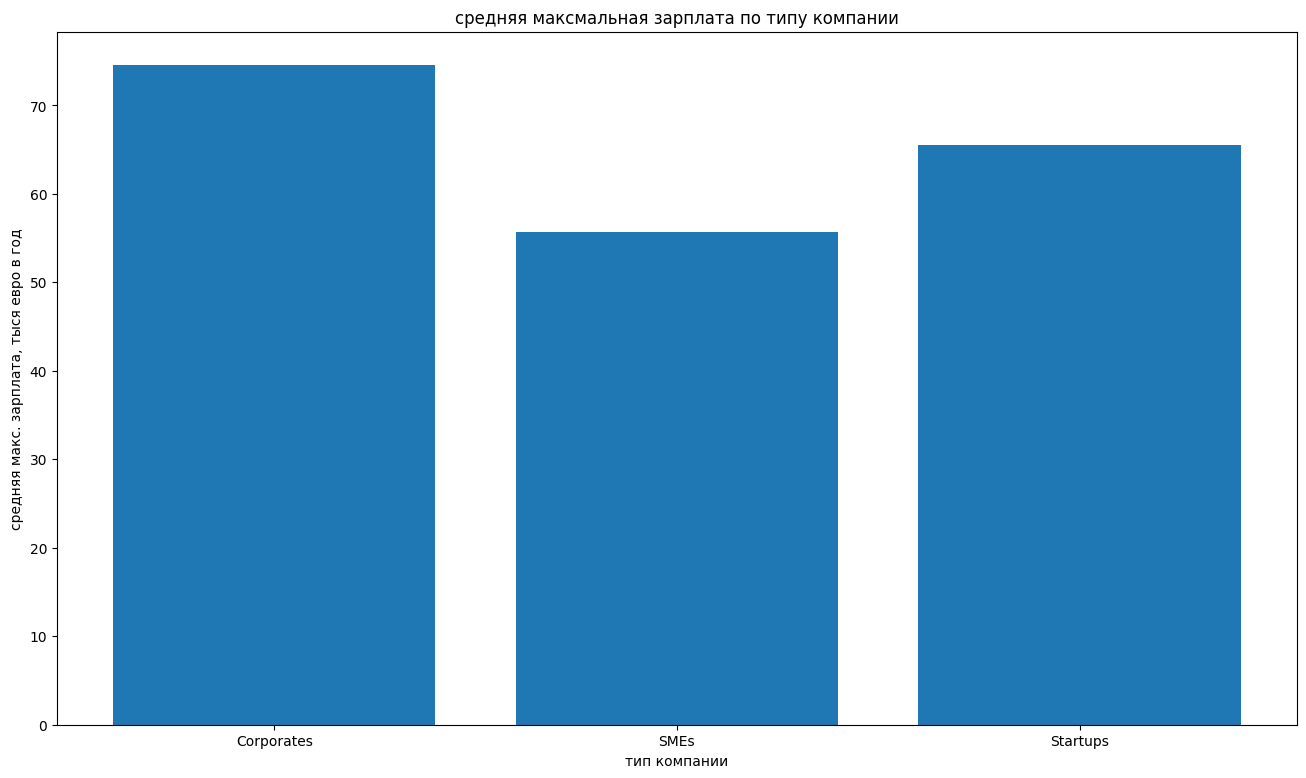

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 9))
plt.bar(salary_by_type.index, salary_by_type["max_eur"])
plt.title("средняя максмальная зарплата по типу компании")
plt.xlabel("тип компании")
plt.ylabel("средняя макс. зарплата, тыся евро в год")
plt.show()

In [32]:
best_countries = (
    table.groupby("country")["max_eur"].mean().sort_values(ascending=False).head(10)
)
best_countries

,max_eur
country,
Switzerland,133.876543
Denmark,91.259259
Norway,87.135802
Luxembourg,84.987654
Germany,79.802469
United Kingdom,77.308642
Ireland,75.604938
Sweden,75.259259
Netherlands,74.913580


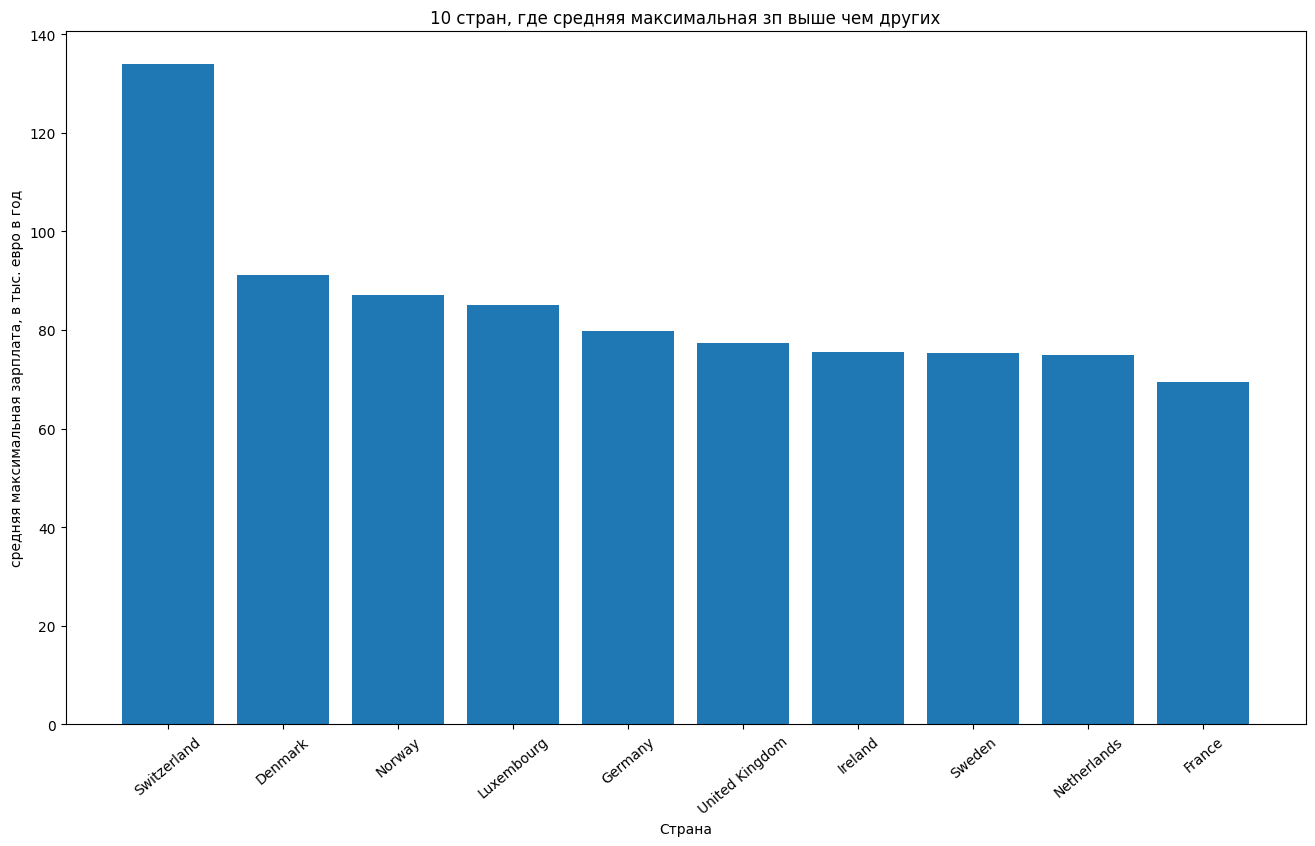

In [41]:
plt.figure(figsize=(16, 9))
plt.bar(best_countries.index, best_countries.values)
plt.title("10 стран, где средняя максимальная зп выше чем других")
plt.xlabel("Страна")
plt.ylabel("средняя максимальная зарплата, в тыс. евро в год")
plt.xticks(rotation=40)
plt.show()

In [36]:
top_roles = (
    table.groupby("role")["max_eur"].mean().sort_values(ascending=False).head(10)
)
top_roles

,max_eur
role,
Software Engineering Manager,91.106667
QA Manager,91.026667
BI Manager,84.693333
Systems Architect,81.706667
Machine Learning Engineer,73.720000
Data Engineer,72.306667
Full Stack Developer,70.426667
Systems Engineer,70.400000
Devops Engineer,70.133333


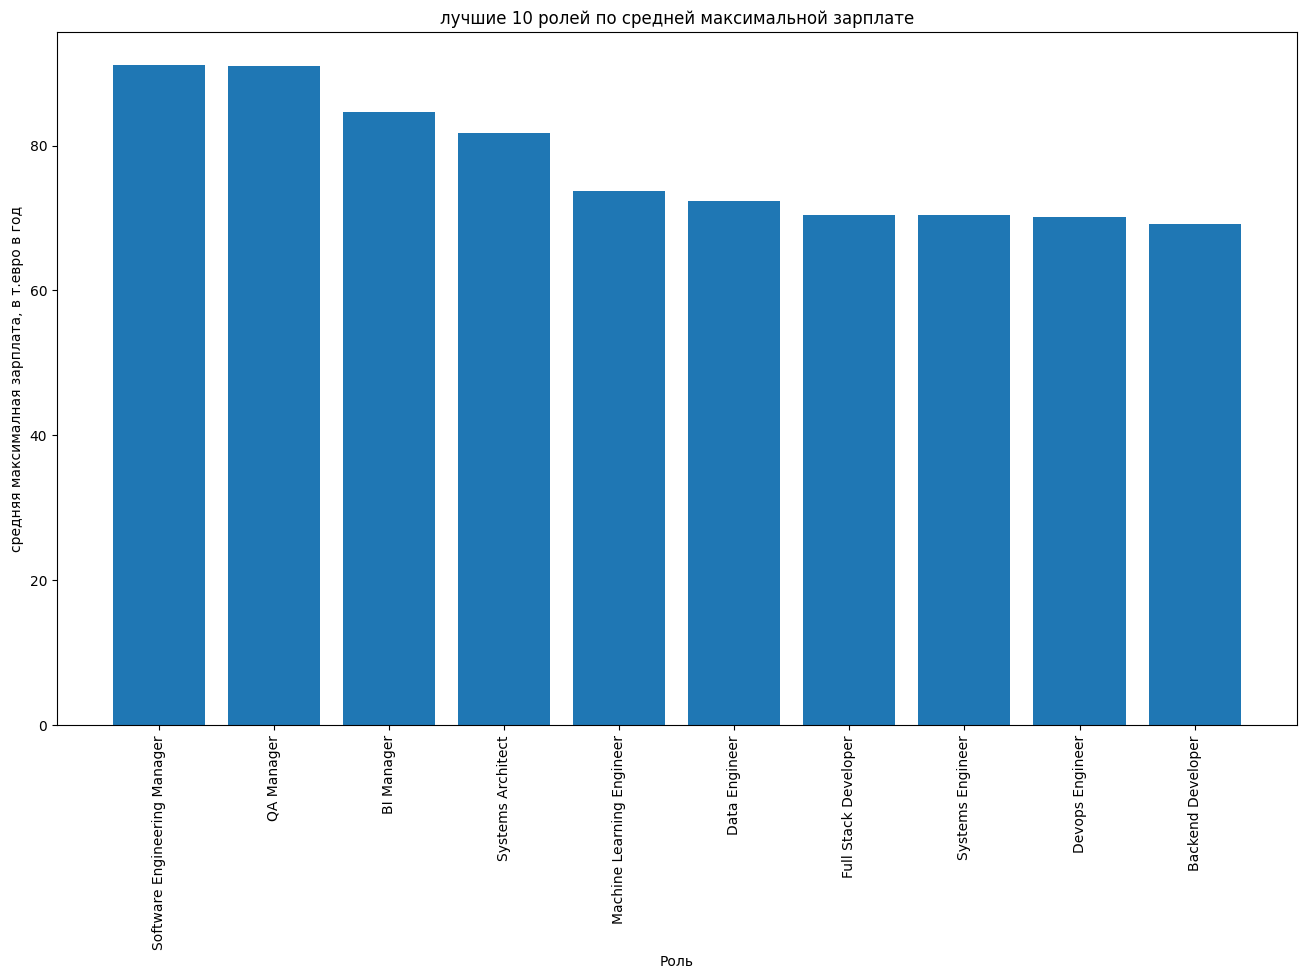

In [43]:
plt.figure(figsize=(16, 9))
plt.bar(top_roles.index, top_roles.values)
plt.title("лучшие 10 ролей по средней максимальной зарплате")
plt.xlabel("Роль")
plt.ylabel("средняя максималная зарплата, в т.евро в год")
plt.xticks(rotation=90)
plt.show()

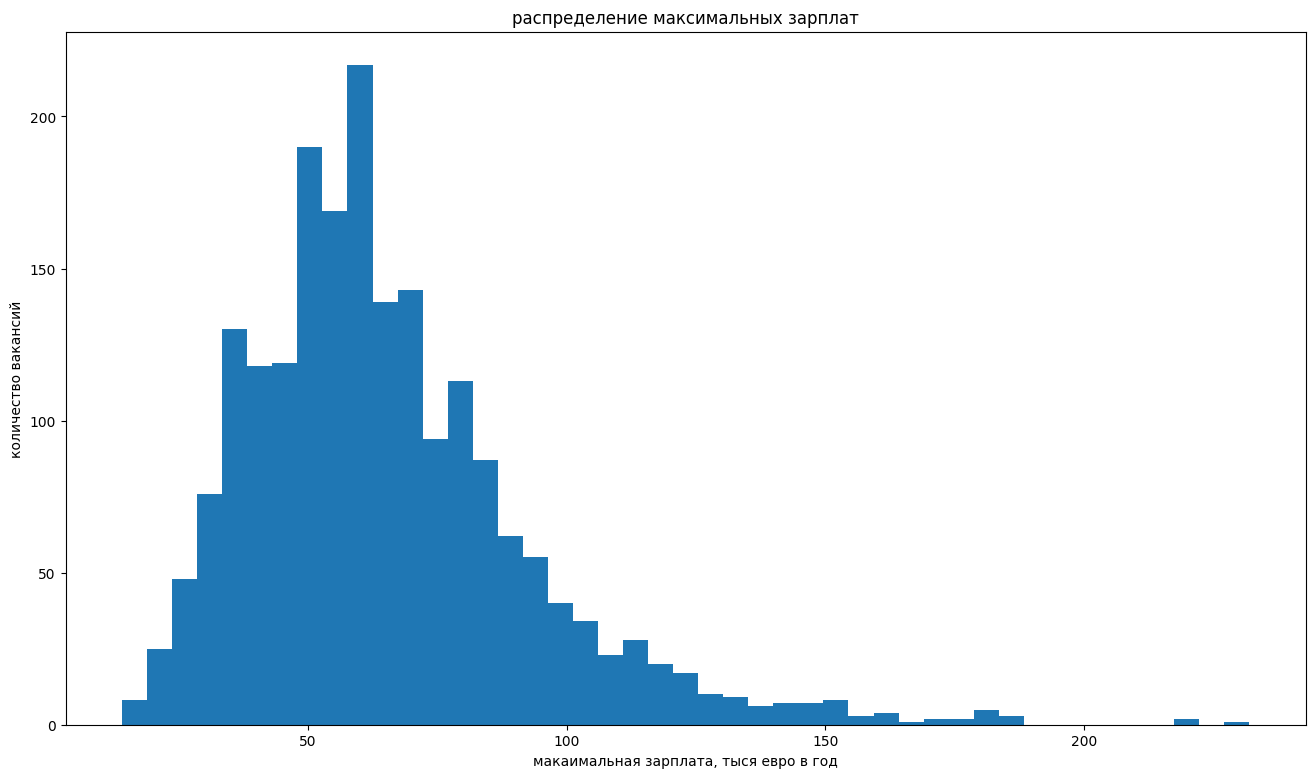

In [44]:
plt.figure(figsize=(16, 9))
plt.hist(df["max_eur"], bins="auto")
plt.title("распределение максимальных зарплат")
plt.xlabel("макаимальная зарплата, тыся евро в год")
plt.ylabel("количество вакансий")
plt.show()